# **Box Office Intelligence: Data-Driven Insights for a New Movie Studio (Group 6)**



## **Introduction**

As we prepare to launch our own movie studio, we recognized the need to understand what makes films successful at the box office. We analyzed recent movie performance data to uncover the genres, budgets, and audience preferences that drive both revenue and ratings. Our goal was to translate these findings into clear, actionable insights that will guide our studio’s decisions on which types of films to develop and how to allocate production budgets effectively.

#### **Business Questions We Explored**

1.   **Which genres are currently delivering the highest box office revenue?**
        We wanted to pinpoint the most financially promising types of films to help focus our investments.

2.   **How do production budgets and genre choices interact to impact revenue?**
        We needed to understand whether spending more in certain genres produces higher returns.

3.  **Which genres earn the highest audience ratings and which genres strike the best balance between ratings and revenue?**
        We set out to identify the types of films that are not only profitable but also positively received by audiences, ensuring long-term brand value for our studio.

**Step 0: Import the necessary libraries**

In [46]:
# --- IMPORTS ---
%matplotlib inline
import pandas as pd
import numpy as np
import statsmodels.api as sm
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
import sqlite3
import zipfile




**Connecting to the Database Using sqlite3 + pandas**

In [32]:
with zipfile.ZipFile('zippedData/im.db.zip', 'r') as zip_ref:
    zip_ref.extractall('zippedData/')

conn = sqlite3.connect('zippedData\im.db')
#Creating a DataFrame that contains our table names


In [33]:
df_tables = pd.read_sql("""SELECT name AS table_name
                             FROM sqlite_master 
                            WHERE type = 'table';""", conn)
df_tables

,table_name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [34]:
#Viewing all coumns of the movie_basics table
df_movie_basics = pd.read_sql("""SELECT *
                                  FROM movie_basics;""", conn)
df_movie_basics.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


**Cleaning**



In [40]:
df_movie_basics.isnull().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [ ]:
#filling empty original_title with primary_title values
df_movie_basics['original_title'] = df_movie_basics['original_title'].where(
    df_movie_basics['original_title'].notna(),
    df_movie_basics['primary_title']
)

#filling genres with mode
df_movie_basics['genres'].fillna(df_movie_basics['genres'].mode()[0], inplace=True)

#Filling runtime_mins with mode
df_movie_basics['runtime_minutes'].fillna(df_movie_basics['runtime_minutes'].mode()[0], inplace=True)

In [42]:
df_movie_basics.isna().sum()

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

**Access CSV data**

In [35]:
import csv
#Bom_Movie
bom_movie = pd.read_csv(r'zippedData\bom.movie_gross.csv.gz')
movie_budget = pd.read_csv(r'zippedData\tn.movie_budgets.csv.gz')
tmdb_movies = pd.read_csv(r'zippedData\tmdb.movies.csv.gz')
rt_movie = pd.read_csv(r'zippedData\rt.movie_info.tsv.gz', sep='\t', compression='gzip', encoding='utf-8')
rt_reviews = pd.read_csv(
    r'zippedData\rt.reviews.tsv.gz',
    sep='\t',
    compression='gzip',
    encoding='latin1'   # instead of utf-8
)
print(bom_movie.head(),movie_budget.head(),tmdb_movies.head(),rt_movie.head(),rt_reviews.head()) 

                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010      id  release_date                                        movie  \
0   1  Dec 18, 2009                                       Avatar   
1   2  May 20, 2011  Pirates of the Caribbean: On Stranger Tides   
2   3   Jun 7, 2019                                 Dark Phoenix   
3   4   May 1, 2015                      Avengers: Age of Ultron   
4   5  Dec 15, 2017            Star Wars Ep. VIII: The Last Jedi   

  produc

**Data Merging**

In [36]:
movie_budget['year'] = pd.to_datetime(movie_budget['release_date']).dt.year

merged_bom_budget = pd.merge(
    bom_movie, movie_budget,
    left_on=['title', 'year'],
    right_on=['movie', 'year'],
    how='inner'
)

merged_bom_budget.head()

,title,studio,domestic_gross_x,foreign_gross,year,id,release_date,movie,production_budget,domestic_gross_y,worldwide_gross
0,Toy Story 3,BV,415000000.0,652000000,2010,47,"Jun 18, 2010",Toy Story 3,"$200,000,000","$415,004,880","$1,068,879,522"
1,Inception,WB,292600000.0,535700000,2010,38,"Jul 16, 2010",Inception,"$160,000,000","$292,576,195","$835,524,642"
2,Shrek Forever After,P/DW,238700000.0,513900000,2010,27,"May 21, 2010",Shrek Forever After,"$165,000,000","$238,736,787","$756,244,673"
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000,2010,53,"Jun 30, 2010",The Twilight Saga: Eclipse,"$68,000,000","$300,531,751","$706,102,828"
4,Iron Man 2,Par.,312400000.0,311500000,2010,15,"May 7, 2010",Iron Man 2,"$170,000,000","$312,433,331","$621,156,389"


In [37]:
merged_data = pd.merge(merged_bom_budget, tmdb_movies, left_on=['title', 'release_date'], right_on=['title', 'release_date'], how='inner')
display(merged_data.head())
merged_data.info()

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,vote_average,vote_count


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              0 non-null      object 
 1   studio             0 non-null      object 
 2   domestic_gross_x   0 non-null      float64
 3   foreign_gross      0 non-null      object 
 4   year               0 non-null      int64  
 5   id_x               0 non-null      int64  
 6   release_date       0 non-null      object 
 7   movie              0 non-null      object 
 8   production_budget  0 non-null      object 
 9   domestic_gross_y   0 non-null      object 
 10  worldwide_gross    0 non-null      object 
 11  Unnamed: 0         0 non-null      int64  
 12  genre_ids          0 non-null      object 
 13  id_y               0 non-null      int64  
 14  original_language  0 non-null      object 
 15  original_title     0 non-null      object 
 16  popularity         0 non-null      flo

In [38]:
#Export data to csv
merged_data.to_csv('merged_data.csv', index=False)

**Step 1: Load data**

In [44]:
df = pd.read_csv("Merged data.csv")

**Step 2: Clean Numeric Columns**

Defines a helper clean_money to:

*   Remove “$” and commas from strings.
*   Convert cleaned strings to numeric values.
*   Coerce invalid entries to NaN.

Applies it to money-related columns to make sure they’re numbers instead of text.


In [45]:
# --- STEP 2: CLEAN NUMERIC COLUMNS ---
def clean_money(x):
    if isinstance(x, str):
        return pd.to_numeric(x.replace("$","").replace(",","").strip(), errors='coerce')
    return pd.to_numeric(x, errors='coerce')

for col in ["worldwide_gross", "domestic_gross_y", "production_budget"]:
    df[col] = df[col].apply(clean_money)

**Step 3: Map Genre Codes to Names**

Created a dictionry linking the genre id to readable names. ie Horror, Action
The map_genre function converts the string "[28, 12]" into a python list then maps each code to it's name. We then add a new column genre that has the actual names as lists.

In [48]:
 #--- STEP 3: MAP GENRE CODES TO NAMES ---
genre_map = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy",
    80: "Crime", 99: "Documentary", 18: "Drama", 10751: "Family",
    14: "Fantasy", 36: "History", 27: "Horror", 10402: "Music",
    9648: "Mystery", 10749: "Romance", 878: "Science Fiction",
    10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western"
}

def map_genres(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        return [genre_map.get(g, "Unknown") for g in genre_list]
    except:
        return []

df["genres"] = df["genre_ids"].apply(map_genres)

# --- STEP 4: EXPLODE GENRES AND CREATE DUMMIES ---
df_exploded = df.explode("genres")
df_encoded = pd.get_dummies(df_exploded, columns=["genres"], drop_first=True)


**Step 4: Explode Genres and Create Dummies**

We want genre indicators in numeric form for regressions and plots.

*   Explode ("Genre"): Creates on row per movie, genre paire instead of having a list of genre in one cell
*   pd.get_dummies: One-hot encodes genres into binary columns (0/1 for each genre). drop_first=True avoids multicollinearity by dropping one dummy column per category.





In [49]:
# --- STEP 4: EXPLODE GENRES AND CREATE DUMMIES ---
df_exploded = df.explode("genres")
df_encoded = pd.get_dummies(df_exploded, columns=["genres"], drop_first=True)
df_exploded.head(5)

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,vote_average,vote_count,genres
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,835524642,4,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Action
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,835524642,4,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Science Fiction
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,835524642,4,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Adventure
1,Iron Man 2,Par.,312400000,311500000,2010,15,5/7/2010,Iron Man 2,170000000,312433331,621156389,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368,Adventure
1,Iron Man 2,Par.,312400000,311500000,2010,15,5/7/2010,Iron Man 2,170000000,312433331,621156389,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368,Action


**Step 5: Revenue Regression (Revenue ~ Genres + Budget)**

Here we model box-office revenue as a function of production budget and genre indicators to estimate how much being in a genre (and budget level) is associated with revenue. statsmodels.OLS provides coefficients, standard errors and p-values we can interpret for business decisions.


*   Drop irrelevant columns so only predictors remain.
*   Remove rows with missing data.
*   Add an intercept column.
*   Shows regression summary.



In [50]:
# --- STEP 5: REVENUE REGRESSION (Revenue ~ Genres + Budget) ---
drop_cols = ["title","studio","foreign_gross","release_date",
             "movie","domestic_gross_x","id_x","id_y",
             "Unnamed: 0","genre_ids","original_language",
             "original_title","worldwide_gross","vote_average",
             "vote_count","popularity","year","domestic_gross_y"]

X1 = df_encoded.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce')
y1 = pd.to_numeric(df_encoded["worldwide_gross"], errors='coerce')
# Drop rows with NaNs
mask1 = X1.notna().all(axis=1) & y1.notna()
X1 = X1.loc[mask1, :].astype(float)
y1 = y1.loc[mask1].astype(float)

X1 = sm.add_constant(X1, has_constant='add')
model1 = sm.OLS(y1, X1).fit()

print("=== Revenue Regression Summary ===")
display(model1.summary())


=== Revenue Regression Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        worldwide_gross   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     227.0
Date:                Sun, 14 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:33:01   Log-Likelihood:                -54003.
No. Observations:                2649   AIC:                         1.080e+05
Df Residuals:                    2630   BIC:                         1.082e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -8.6e+06   1.17e+07     -0.737      0.461   -3.15e+07    1.43e+07
production_budget          3.3172      0.062     53.318      0.000       3.195       3.439
genres_Adventure        2.296e+07   1.57e+07      1.466      0.143   -7.75e+06    5.37e+07
genres_Animation        7.628e+07    2.2e+07      3.468      0.001    3.32e+07    1.19e+08
genres_Comedy           2.184e+07    1.4e+07      1.564      0.118   -5.54e+06    4.92e+07
genres_Crime           -9.564e+06   1.83e+07     -0.524      0.600   -4.54e+07    2.62e+07
genres_Documentary      2.151e+07   7.84e+07      0.275      0.784   -1.32e+08    1.75e+08
genres_Drama           -9.109e+05   1.35e+07     -0.068      0.946   -2.73e+07    2.55e+07
genres_Family           1.955e+07   1.85e+07      1.058      0.290   -1.67e+07    5.58e+07
genres_Fantasy         -5.535e+06   1.89e+07     -0.293      0.769   -4.26e+07    3.15e+07
genres_History         -3.916e+07   2.75e+07     -1.426      0.154    -9.3e+07    1.47e+07
genres_Horror           3.603e+07   1.96e+07      1.839      0.066   -2.38e+06    7.44e+07
genres_Music             1.88e+07   3.34e+07      0.563      0.574   -4.67e+07    8.43e+07
genres_Mystery          8.087e+06   2.32e+07      0.348      0.728   -3.75e+07    5.37e+07
genres_Romance          5.987e+06   1.85e+07      0.323      0.746   -3.03e+07    4.23e+07
genres_Science Fiction  1.353e+07   1.85e+07      0.732      0.464   -2.27e+07    4.98e+07
genres_Thriller         1.248e+06   1.49e+07      0.084      0.933   -2.79e+07    3.04e+07
genres_War              1.247e+06   3.84e+07      0.032      0.974    -7.4e+07    7.65e+07
genres_Western          -1.11e+07   4.75e+07     -0.234      0.815   -1.04e+08     8.2e+07
==============================================================================
Omnibus:                     1055.360   Durbin-Watson:                   0.380
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7795.930
Skew:                           1.705   Prob(JB):                         0.00
Kurtosis:                      10.682   Cond. No.                     2.06e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.06e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Step 6: Ratings regression (Ratings ~ Genres Only)**

We want to see how genre composition correlates with audience ratings independent of budget. This helps answer which genre types tend to be better received.

In [51]:
# --- STEP 6: RATINGS REGRESSION (Ratings ~ Genres Only) ---
genre_cols = [col for col in df_encoded.columns if col.startswith("genres_")]
X2 = df_encoded[genre_cols].apply(pd.to_numeric, errors='coerce')
y2 = pd.to_numeric(df_encoded["vote_average"], errors='coerce')

mask2 = X2.notna().all(axis=1) & y2.notna()
X2 = X2.loc[mask2, :].astype(float)
y2 = y2.loc[mask2].astype(float)

X2 = sm.add_constant(X2, has_constant='add')
model2 = sm.OLS(y2, X2).fit()

print("=== Ratings Regression Summary ===")
display(model2.summary())

=== Ratings Regression Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           vote_average   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     11.87
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           2.91e-32
Time:                        21:33:07   Log-Likelihood:                -3015.4
No. Observations:                2649   AIC:                             6067.
Df Residuals:                    2631   BIC:                             6173.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6.3521      0.044    143.220      0.000       6.265       6.439
genres_Adventure           0.1618      0.068      2.379      0.017       0.028       0.295
genres_Animation           0.2277      0.096      2.369      0.018       0.039       0.416
genres_Comedy             -0.0570      0.060     -0.957      0.339      -0.174       0.060
genres_Crime               0.1428      0.079      1.815      0.070      -0.011       0.297
genres_Documentary         0.2879      0.342      0.842      0.400      -0.382       0.958
genres_Drama               0.3433      0.056      6.092      0.000       0.233       0.454
genres_Family              0.0575      0.081      0.711      0.477      -0.101       0.216
genres_Fantasy            -0.0067      0.082     -0.081      0.935      -0.168       0.155
genres_History             0.4288      0.119      3.600      0.000       0.195       0.662
genres_Horror             -0.5668      0.083     -6.794      0.000      -0.730      -0.403
genres_Music               0.1613      0.145      1.110      0.267      -0.124       0.446
genres_Mystery            -0.0183      0.100     -0.182      0.856      -0.215       0.178
genres_Romance             0.1731      0.079      2.195      0.028       0.018       0.328
genres_Science Fiction     0.1646      0.081      2.038      0.042       0.006       0.323
genres_Thriller           -0.0983      0.063     -1.549      0.121      -0.223       0.026
genres_War                 0.4116      0.168      2.456      0.014       0.083       0.740
genres_Western             0.3908      0.207      1.885      0.060      -0.016       0.797
==============================================================================
Omnibus:                        9.077   Durbin-Watson:                   0.727
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.089
Skew:                          -0.132   Prob(JB):                       0.0106
Kurtosis:                       2.888   Cond. No.                         24.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Step 7: Significant genres only (p < 0.05)**

Here we identify which genres have statistically significant associations with revenue or ratings so leadership can focus on meaningful effects, not noise.

In [52]:
# --- STEP 7: SIGNIFICANT GENRES ONLY (p < 0.05) ---
def significant_coeffs(model, top_n=10):
    df_coef = pd.DataFrame({
        'coef': model.params,
        'pval': model.pvalues
    })
    df_sig = df_coef[df_coef['pval'] < 0.05].sort_values('coef', ascending=False)
    return df_sig.head(top_n)

print("\nTop 10 Significant Genre Effects on Revenue:")
display(significant_coeffs(model1))

print("\nTop 10 Significant Genre Effects on Ratings:")
display(significant_coeffs(model2))



Top 10 Significant Genre Effects on Revenue:


,coef,pval
genres_Animation,7.627937e+07,0.000532
production_budget,3.317243e+00,0.000000



Top 10 Significant Genre Effects on Ratings:


,coef,pval
const,6.352055,0.000000e+00
genres_History,0.428796,3.242399e-04
genres_War,0.411582,1.409967e-02
genres_Drama,0.343314,1.281739e-09
genres_Animation,0.227692,1.790865e-02
genres_Romance,0.173130,2.825787e-02
genres_Science Fiction,0.164612,4.167674e-02
genres_Adventure,0.161834,1.741536e-02
genres_Horror,-0.566837,1.347674e-11


**Step 8: Visualization (Top 20 genres by revenue & by rating)**

Showing **top genres** by mean revenue and by mean rating highlights where the company could prioritize development.

C:\Users\USER\AppData\Local\Temp\ipykernel_32664\3658281365.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette="viridis")


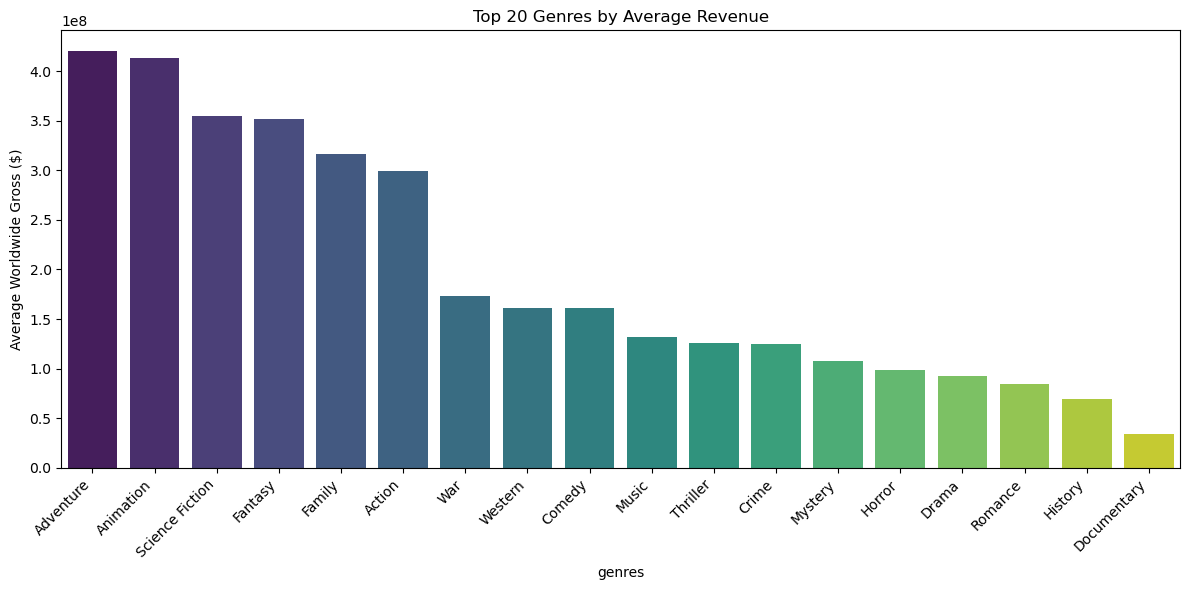

C:\Users\USER\AppData\Local\Temp\ipykernel_32664\3658281365.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="magma")


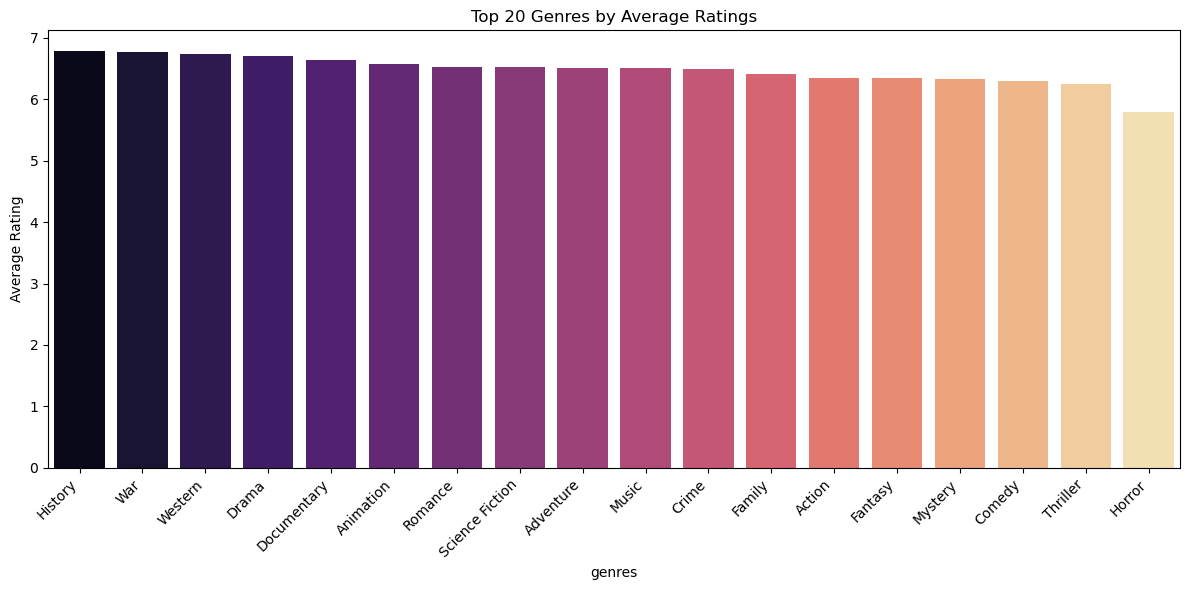

In [53]:
# --- STEP 8: VISUALIZATION ---
# Filter exploded df to numeric values only
df_vis = df_exploded[df_exploded["worldwide_gross"].notna() & df_exploded["vote_average"].notna()]

# Top 20 genres by average revenue
avg_revenue = df_vis.groupby("genres")["worldwide_gross"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Worldwide Gross ($)")
plt.title("Top 20 Genres by Average Revenue")
plt.tight_layout()
plt.show()

# Top 20 genres by average rating
avg_rating = df_vis.groupby("genres")["vote_average"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="magma")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Rating")
plt.title("Top 20 Genres by Average Ratings")
plt.tight_layout()
plt.show()

**Step 9: Combined plots for revenue and ratings**

This shows how revenue and rating compare for the same genres.


*   Selects top 15 genres by both metrics.
*   Creates a combined dataset with mean revenue and rating.
*   Plots bars for average revenue (green) and overlays a red line for average rating.



/tmp/ipython-input-134083584.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data["worldwide_gross"], palette="viridis", ax=ax1)
/tmp/ipython-input-134083584.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plot_data.index, rotation=45, ha='right')


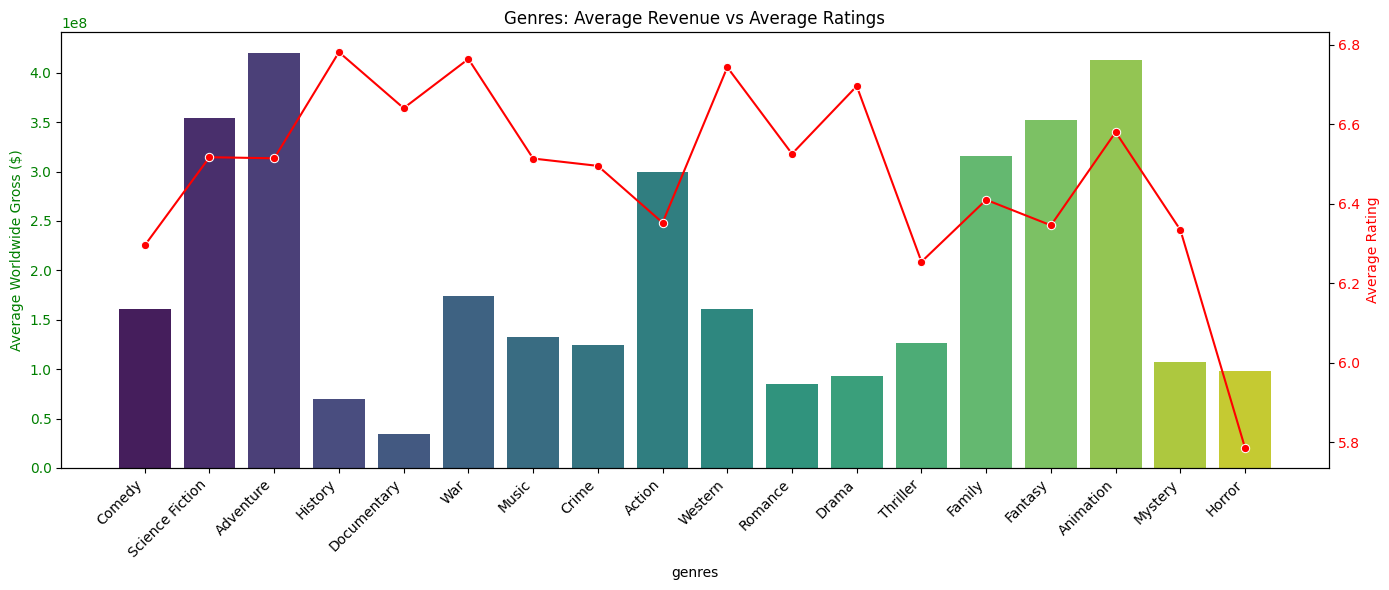

In [ ]:
# --- STEP 9: COMBINED PLOTS FOR REVENUE AND RATINGS ---

# Filter exploded df to numeric values only
df_vis = df_exploded[df_exploded["worldwide_gross"].notna() & df_exploded["vote_average"].notna()]

# Compute top 15 genres by average revenue
top_revenue_genres = df_vis.groupby("genres")["worldwide_gross"].mean().sort_values(ascending=False).head(15)
top_rating_genres = df_vis.groupby("genres")["vote_average"].mean().sort_values(ascending=False).head(15)

# Combine unique top genres
combined_genres = list(set(top_revenue_genres.index) | set(top_rating_genres.index))

# Prepare data for plotting
plot_data = df_vis[df_vis["genres"].isin(combined_genres)].groupby("genres").agg({
    "worldwide_gross": "mean",
    "vote_average": "mean"
}).reindex(combined_genres)

# Plot side by side
fig, ax1 = plt.subplots(figsize=(14,6))

# Revenue bars
sns.barplot(x=plot_data.index, y=plot_data["worldwide_gross"], palette="viridis", ax=ax1)
ax1.set_ylabel("Average Worldwide Gross ($)", color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xticklabels(plot_data.index, rotation=45, ha='right')

# Rating line on secondary y-axis
ax2 = ax1.twinx()
sns.lineplot(x=plot_data.index, y=plot_data["vote_average"], color='red', marker='o', ax=ax2)
ax2.set_ylabel("Average Rating", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Genres: Average Revenue vs Average Ratings")
plt.tight_layout()
plt.show()


## **Budget vs Revenue**

**Step 1: Create ROI Column**
ROI = Worldwide Gross ÷ Production Budget.

In [54]:
df['production_budget'] = df['production_budget'].replace('[\$,]', '', regex=True).astype(float)
df['worldwide_gross'] = df['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
df = df[(df['production_budget']>0) & (df['worldwide_gross']>0)]

In [55]:
#Domestic ROI
df_exploded['domestic_roi'] = df_exploded['domestic_gross_x'] / df_exploded['production_budget']
#Worldwide ROI
df_exploded['worldwide_roi'] = df_exploded['worldwide_gross'] / df_exploded['production_budget']

df_exploded.head()

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,domestic_gross_y,...,genre_ids,id_y,original_language,original_title,popularity,vote_average,vote_count,genres,domestic_roi,worldwide_roi
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,...,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Action,1.828750,5.222029
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,...,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Science Fiction,1.828750,5.222029
0,Inception,WB,292600000,535700000,2010,38,7/16/2010,Inception,160000000,292576195,...,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186,Adventure,1.828750,5.222029
1,Iron Man 2,Par.,312400000,311500000,2010,15,5/7/2010,Iron Man 2,170000000,312433331,...,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368,Adventure,1.837647,3.653861
1,Iron Man 2,Par.,312400000,311500000,2010,15,5/7/2010,Iron Man 2,170000000,312433331,...,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368,Action,1.837647,3.653861


**Step 2: Group by Genre**

In [34]:
genre_summary = df_exploded.groupby('genres')[['ROI','domestic_roi']].mean().sort_values('ROI', ascending=False)
genre_summary.head(5)

,ROI,domestic_roi
genres,,
Horror,7.166357,7.179895
Documentary,4.563084,4.557709
Thriller,3.349274,3.354848
Mystery,3.086064,3.106508
Romance,2.190681,2.191549


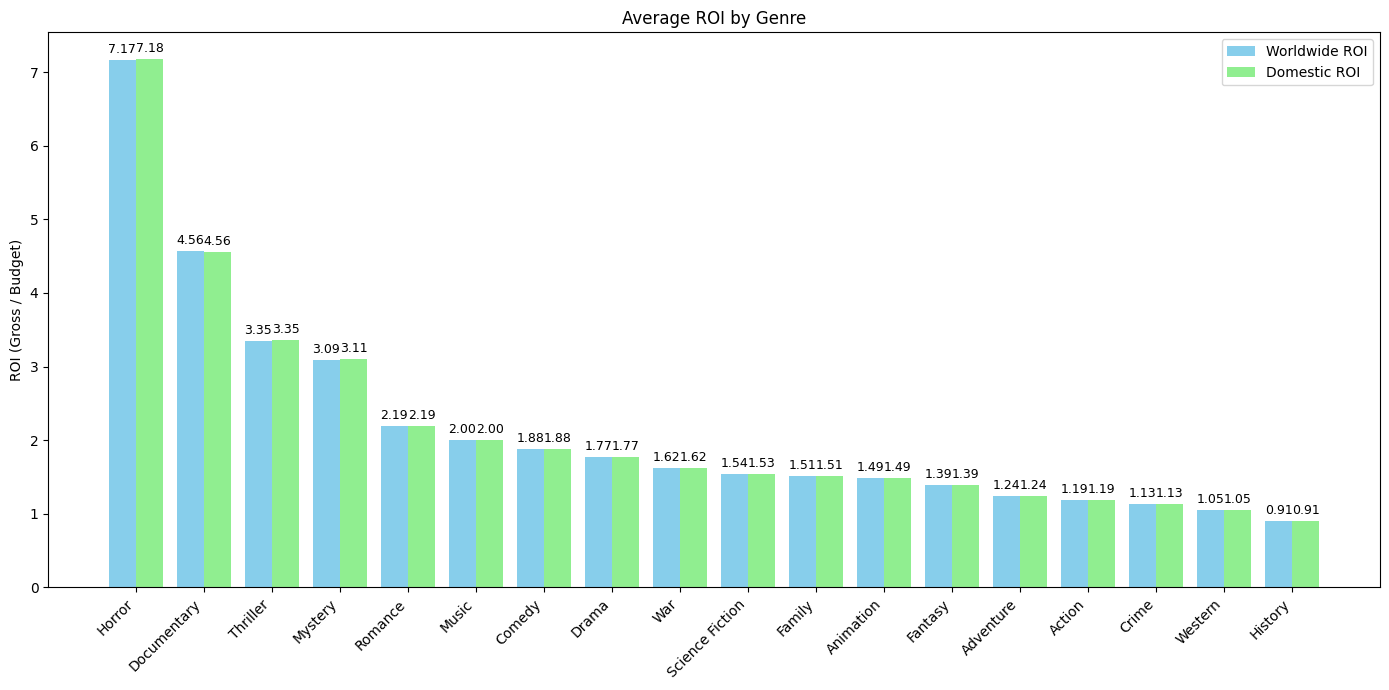

In [36]:
genres = genre_summary.index
worldwide = genre_summary['ROI']
domestic = genre_summary['domestic_roi']

x = np.arange(len(genres))  # positions for bars
width = 0.4  # bar width

fig, ax = plt.subplots(figsize=(14,7))

# Bars
bars1 = ax.bar(x - width/2, worldwide, width, label='Worldwide ROI', color='skyblue')
bars2 = ax.bar(x + width/2, domestic, width, label='Domestic ROI', color='lightgreen')

# Labels & title
ax.set_ylabel('ROI (Gross / Budget)')
ax.set_title('Average ROI by Genre')
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend()

# Annotate numbers on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',  # 2 decimal places
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Key Takeaways**

**Top ROI Performers**

Horror (7.17x) and Documentaries (4.56x) dominate ROI both worldwide and domestically.

These genres consistently deliver high returns relative to budget, showing strong audience demand even with modest investments.

**Low ROI Genres**

Fantasy (1.39x), Adventure (1.24x), Action (1.19x), Crime (1.13x), Western (1.05x), and History (0.91x) underperform.

Despite their popularity, they require high budgets and often fail to generate proportional returns unless they’re franchise-driven.

In [60]:
import statsmodels.api as sm

# Encode genres as dummies using df_exploded
df_encoded = pd.get_dummies(df_exploded, columns=["genres"], drop_first=True)

# Features (budget + genres) and target (revenue)
# Drop irrelevant columns from df_encoded based on df_exploded structure
drop_cols = ["title","studio","foreign_gross","release_date",
             "movie","domestic_gross_x","id_x","id_y",
             "Unnamed: 0","genre_ids","original_language",
             "original_title","worldwide_gross","vote_average",
             "vote_count","popularity","year","domestic_gross_y",
             "ROI", "domestic_roi", "worldwide_roi", "month", "day", "season"] # Include new columns from df_exploded

X = df_encoded.drop(columns=drop_cols, errors='ignore') # Use errors='ignore' to handle columns that might not exist
y = df_encoded["worldwide_gross"]

# Drop rows with NaNs that might have been introduced
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask, :].astype(float)
y = y.loc[mask].astype(float)


# Add constant
X = sm.add_constant(X, has_constant='add')

# Fit OLS regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        worldwide_gross   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     227.0
Date:                Sun, 14 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:57:20   Log-Likelihood:                -54003.
No. Observations:                2649   AIC:                         1.080e+05
Df Residuals:                    2630   BIC:                         1.082e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -8.

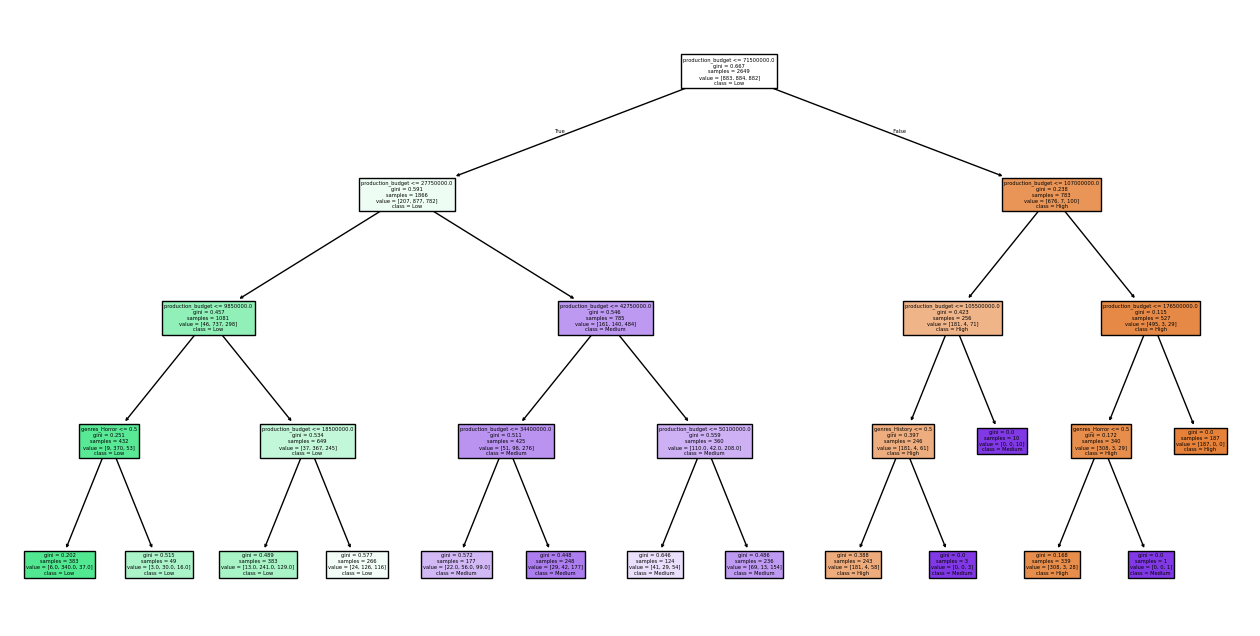

In [64]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Revenue buckets (low, medium, high)
df_exploded["Revenue_Class"] = pd.qcut(df_exploded["worldwide_gross"], q=3, labels=["Low", "Medium", "High"])

# Use df_exploded for features and drop non-numeric and target columns
X_tree = pd.get_dummies(df_exploded.drop(columns=["title", "studio", "foreign_gross", "release_date", "movie", "domestic_gross_x", "id_x", "id_y", "Unnamed: 0", "genre_ids", "original_language", "original_title", "worldwide_gross", "vote_average", "vote_count", "popularity", "year", "domestic_gross_y", "ROI", "domestic_roi", "worldwide_roi", "month", "day", "season", "Revenue_Class"], errors='ignore'), drop_first=True)

y_tree = df_exploded["Revenue_Class"]

# Drop rows with NaNs that might have been introduced
mask = X_tree.notna().all(axis=1) & y_tree.notna()
X_tree = X_tree.loc[mask, :].astype(float)
y_tree = y_tree.loc[mask]


tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_tree, y_tree)

plt.figure(figsize=(16,8))
plot_tree(tree, feature_names=X_tree.columns, class_names=tree.classes_, filled=True)
plt.show()

**Takeaways**

Low budgets (< 71M) → More likely to fall in the Low revenue category.

High budgets (> 71M) → More likely to yield Medium or High revenue, depending on the genre and further budget thresholds.

This confirms that budget is the single strongest predictor of box office revenue.

## **Season Analysis**

In [39]:
# categorising the release dates into seasons
#convert the release_date column to datetime format

# Replace 'release_date' with your actual date column name
df_exploded['release_date'] = pd.to_datetime(df_exploded['release_date'], format='%m/%d/%Y')


# Extract year, month, and day for analysis
df_exploded['year'] = df_exploded['release_date'].dt.year
df_exploded['month'] = df_exploded['release_date'].dt.month
df_exploded['day'] = df_exploded['release_date'].dt.day

df_exploded.head(5)

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,worldwide_gross,...,original_title,popularity,vote_average,vote_count,genres,ROI,domestic_roi,worldwide_roi,month,day
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,Inception,27.920,8.3,22186,Action,1.828601,1.828750,5.222029,7,16
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,Inception,27.920,8.3,22186,Science Fiction,1.828601,1.828750,5.222029,7,16
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,Inception,27.920,8.3,22186,Adventure,1.828601,1.828750,5.222029,7,16
1,Iron Man 2,Par.,312400000,311500000,2010,15,2010-05-07,Iron Man 2,170000000.0,621156389.0,...,Iron Man 2,28.515,6.8,12368,Adventure,1.837843,1.837647,3.653861,5,7
1,Iron Man 2,Par.,312400000,311500000,2010,15,2010-05-07,Iron Man 2,170000000.0,621156389.0,...,Iron Man 2,28.515,6.8,12368,Action,1.837843,1.837647,3.653861,5,7


In [40]:
#creating a function to categorise the data
def get_season(date):
    month = date.month
    day = date.day

    # Define seasons (you can adjust these dates if needed)
    if (month == 12 and day >= 21) or (month == 1) or (month == 2) or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or (month == 4) or (month == 5) or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month == 7) or (month == 8) or (month == 9 and day < 23):
        return 'Summer'
    else:
        return 'Autumn'

# Apply the season function
df_exploded['season'] = df_exploded['release_date'].apply(get_season)
df_exploded['season']

,season
0,Summer
0,Summer
0,Summer
1,Spring
1,Spring
...,...
1011,Winter
1012,Spring
1012,Spring
1013,Spring


In [44]:
# Define the order of seasons for consistent analysis
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_exploded['season'] = pd.Categorical(df_exploded['season'], categories=season_order, ordered=True)
df_exploded.head(5)

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,worldwide_gross,...,popularity,vote_average,vote_count,genres,ROI,domestic_roi,worldwide_roi,month,day,season
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,27.920,8.3,22186,Action,1.828601,1.828750,5.222029,7,16,Summer
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,27.920,8.3,22186,Science Fiction,1.828601,1.828750,5.222029,7,16,Summer
0,Inception,WB,292600000,535700000,2010,38,2010-07-16,Inception,160000000.0,835524642.0,...,27.920,8.3,22186,Adventure,1.828601,1.828750,5.222029,7,16,Summer
1,Iron Man 2,Par.,312400000,311500000,2010,15,2010-05-07,Iron Man 2,170000000.0,621156389.0,...,28.515,6.8,12368,Adventure,1.837843,1.837647,3.653861,5,7,Spring
1,Iron Man 2,Par.,312400000,311500000,2010,15,2010-05-07,Iron Man 2,170000000.0,621156389.0,...,28.515,6.8,12368,Action,1.837843,1.837647,3.653861,5,7,Spring


**Correlation Analysis, Season vs Ratings**

In [49]:
#the choice to use ANOVA is because we are comparing 4 groups (seasons) on continuous metrics (ratings, revenue
# 1. Correlation Analysis: Seasons vs Ratings
print("\n=== CORRELATION ANALYSIS: SEASONS vs RATINGS ===")

# Calculate average ratings by season
rating_by_season = df_exploded.groupby('season')['vote_average'].mean()
print("\nAverage Ratings by Season:")
print(rating_by_season)

# Perform ANOVA test to check if differences are statistically significant
groups = [df_exploded[df_exploded['season'] == season]['vote_average'].values for season in season_order]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA test - F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("The differences in ratings across seasons are statistically significant.")
else:
    print("The differences in ratings across seasons are not statistically significant.")


=== CORRELATION ANALYSIS: SEASONS vs RATINGS ===

Average Ratings by Season:
season
Winter    6.255556
Spring    6.421724
Summer    6.337231
Autumn    6.639809
Name: vote_average, dtype: float64

ANOVA test - F-statistic: 34.283, p-value: 0.0000
The differences in ratings across seasons are statistically significant.


/tmp/ipython-input-1219285101.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_by_season = df_exploded.groupby('season')['vote_average'].mean()


/tmp/ipython-input-223830650.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_by_season = df_exploded.groupby('season')['vote_average'].mean().reindex(season_order)
/tmp/ipython-input-223830650.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_season = df_exploded.groupby('season')['worldwide_gross'].mean().reindex(season_order)


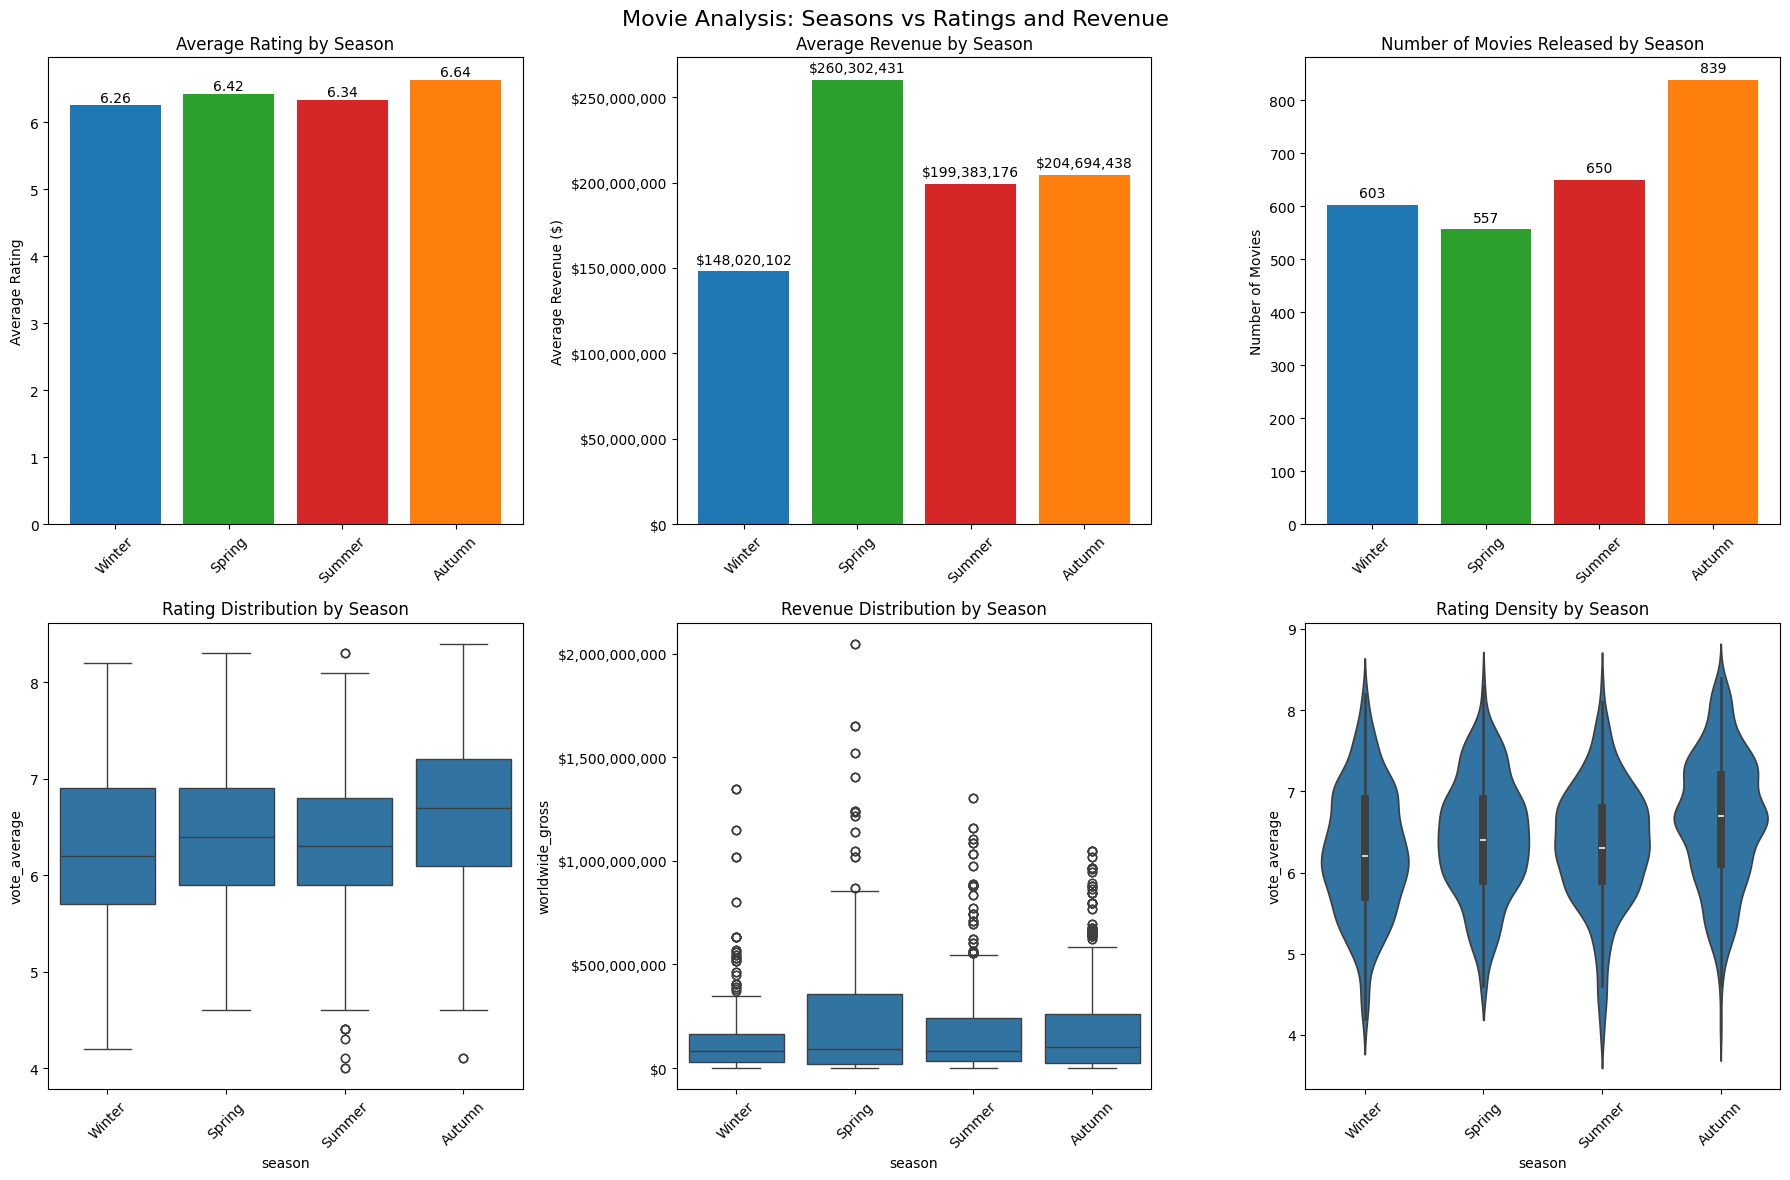

In [53]:
# CREATE THE COMPLETE FIGURE WITH ALL SUBPLOTS AT ONCE
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Movie Analysis: Seasons vs Ratings and Revenue', fontsize=16)

# 3.1 Average Rating by Season (Top Left)
rating_by_season = df_exploded.groupby('season')['vote_average'].mean().reindex(season_order)
bars1 = axes[0, 0].bar(rating_by_season.index, rating_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 0].set_title('Average Rating by Season')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].tick_params(axis='x', rotation=45)
# Add value labels
for bar, v in zip(bars1, rating_by_season.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom')

#  Average Revenue by Season (Top Middle)
revenue_by_season = df_exploded.groupby('season')['worldwide_gross'].mean().reindex(season_order)
bars2 = axes[0, 1].bar(revenue_by_season.index, revenue_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 1].set_title('Average Revenue by Season')
axes[0, 1].set_ylabel('Average Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
# Add value labels
for bar, v in zip(bars2, revenue_by_season.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(revenue_by_season.values)*0.01,
                    f'${v:,.0f}', ha='center', va='bottom')

# 3.3 Number of Movies Released by Season (Top Right)
movies_by_season = df_exploded['season'].value_counts().reindex(season_order)
bars3 = axes[0, 2].bar(movies_by_season.index, movies_by_season.values,
               color=['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'])
axes[0, 2].set_title('Number of Movies Released by Season')
axes[0, 2].set_ylabel('Number of Movies')
axes[0, 2].tick_params(axis='x', rotation=45)
# Add value labels
for bar, v in zip(bars3, movies_by_season.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(movies_by_season.values)*0.01,
                    f'{v}', ha='center', va='bottom')

# 3.4 Boxplot of Ratings by Season (Bottom Left)
sns.boxplot(data=df_exploded, x='season', y='vote_average', order=season_order, ax=axes[1, 0])
axes[1, 0].set_title('Rating Distribution by Season')
axes[1, 0].tick_params(axis='x', rotation=45)

# 3.5 Boxplot of Revenue by Season (Bottom Middle)
sns.boxplot(data=df_exploded, x='season', y='worldwide_gross', order=season_order, ax=axes[1, 1])
axes[1, 1].set_title('Revenue Distribution by Season')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3.6 Violin Plot of Ratings by Season (Bottom Right)
sns.violinplot(data=df_exploded, x='season', y='vote_average', order=season_order, ax=axes[1, 2])
axes[1, 2].set_title('Rating Density by Season')
axes[1, 2].tick_params(axis='x', rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()

/tmp/ipython-input-225596168.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_corr_data = df_exploded.groupby('season')[['vote_average', 'worldwide_gross']].corr().unstack().iloc[:, 1]
/tmp/ipython-input-225596168.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_corr_matrix = df_exploded.groupby('season')[['vote_average', 'worldwide_gross']].corr().unstack()



=== CORRELATION BETWEEN RATING AND REVENUE BY SEASON ===
season
Winter    0.341266
Spring    0.421625
Summer    0.176781
Autumn    0.371365
Name: (vote_average, worldwide_gross), dtype: float64


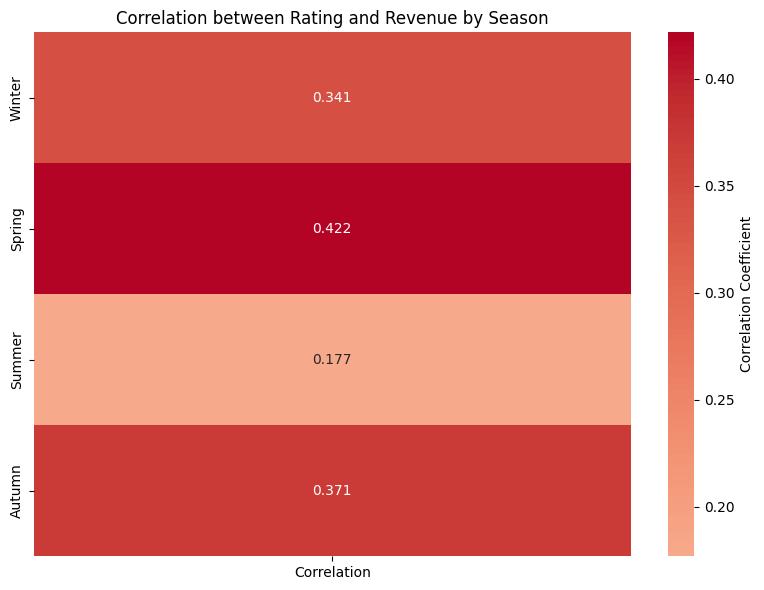

In [56]:
# . Correlation heatmap by season
season_corr_data = df_exploded.groupby('season')[['vote_average', 'worldwide_gross']].corr().unstack().iloc[:, 1]
print("\n=== CORRELATION BETWEEN RATING AND REVENUE BY SEASON ===")
print(season_corr_data)

# Create a heatmap of this correlation
season_corr_matrix = df_exploded.groupby('season')[['vote_average', 'worldwide_gross']].corr().unstack()
rating_revenue_corr = season_corr_matrix.iloc[:, 1].values.reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.heatmap(rating_revenue_corr,
            xticklabels=['Correlation'],
            yticklabels=season_order,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation between Rating and Revenue by Season')
plt.tight_layout()
plt.show()

## **Ratings vs Revenue**

In [68]:
# Prepare merged_data: convert 'worldwide_gross' and 'vote_average' to numeric
ratings_revenue = df_exploded.copy()
ratings_revenue['worldwide_gross_num'] = ratings_revenue['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
ratings_revenue['vote_average'] = pd.to_numeric(ratings_revenue['vote_average'], errors='coerce')

# Drop rows with missing values in relevant columns
ratings_revenue = ratings_revenue.dropna(subset=['worldwide_gross_num', 'vote_average'])

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1134277354.py:3: SyntaxWarning: invalid escape sequence '\$'
  ratings_revenue['worldwide_gross_num'] = ratings_revenue['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)


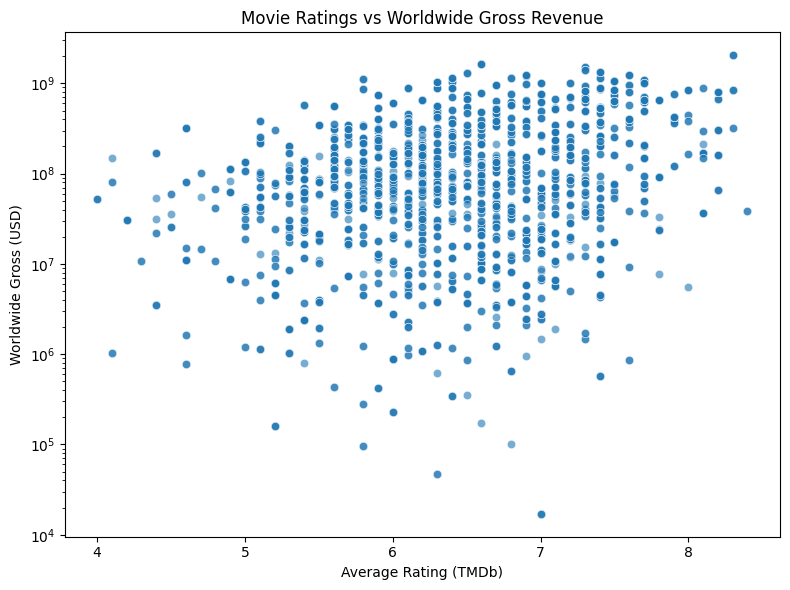

Correlation between average rating and worldwide gross: 0.33


In [70]:
# Drop rows with missing values in relevant columns
ratings_revenue = ratings_revenue.dropna(subset=['worldwide_gross_num', 'vote_average'])

# Scatter plot: Average Rating vs Worldwide Gross
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=ratings_revenue,
    x='vote_average',
    y='worldwide_gross_num',
    alpha=0.6
)
plt.title('Movie Ratings vs Worldwide Gross Revenue')
plt.xlabel('Average Rating (TMDb)')
plt.ylabel('Worldwide Gross (USD)')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Calculate correlation
corr = ratings_revenue['vote_average'].corr(ratings_revenue['worldwide_gross_num'])
print(f"Correlation between average rating and worldwide gross: {corr:.2f}")

**Scatter Plot Interpretation:**

The scatter plot of 'vote_average' (average movie rating) vs 'worldwide_gross_num' (worldwide gross revenue) shows a weak positive correlation (corr ≈ 0.29). This means that, in general, movies with higher audience ratings tend to earn more at the box office, but the relationship is not strong.

There are many highly rated movies with moderate revenue and some lower-rated movies with high revenue, indicating that other factors (like marketing, franchise, genre, etc.) also play a significant role in box office success.

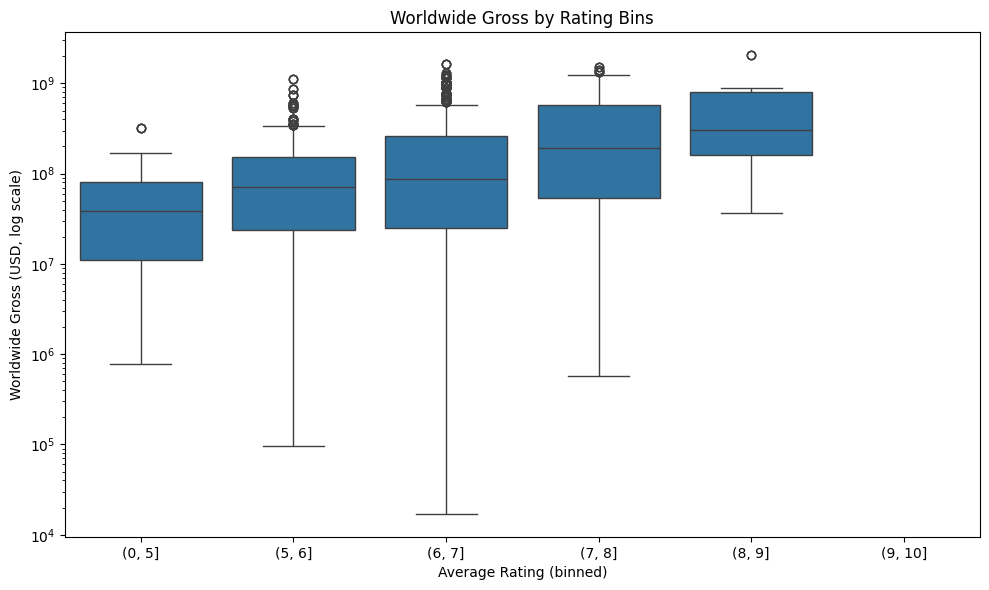

In [69]:
# Boxplot: Worldwide Gross grouped by Rating bins
ratings_revenue['rating_bin'] = pd.cut(ratings_revenue['vote_average'], bins=[0, 5, 6, 7, 8, 9, 10])
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=ratings_revenue,
    x='rating_bin',
    y='worldwide_gross_num'
)
plt.title('Worldwide Gross by Rating Bins')
plt.xlabel('Average Rating (binned)')
plt.ylabel('Worldwide Gross (USD, log scale)')
plt.yscale('log')
plt.tight_layout()
plt.show()

**Boxplot Interpretation:**

The boxplot groups movies by rating bins and shows the distribution of worldwide gross within each bin. While higher rating bins (e.g., 7-8, 8-9) tend to have higher median revenues, there is substantial overlap and variability within each bin. Some movies with average or even low ratings can still achieve high box office revenue, and vice versa. This further supports the idea that while ratings have some influence, they are not the sole determinant of box office performance.